# CS5143 — NLP Spring 2026
## Programming Assignment 2: Product Title Conciseness Classifier

**Task:** Predict whether an e-commerce product title is concise (1) or not (0).  
**Framing:** Regression — model outputs a probability in [0, 1]; evaluated on RMSE.  
**Models:**
- Model 1: Multi-input BiLSTM (text + structured features)
- Model 2: Fine-tuned DistilBERT (text + structured features)

**Environment:** Kaggle, T4 x2 GPU  
**Dataset:** CS5143-NLP_PA2_data_train.csv (~36k rows)

## 1. Setup & Dependencies

In [35]:
# Install HuggingFace transformers (not pre-installed on all Kaggle images)
!pip install transformers torch -q

In [36]:
import os, re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import torch
from transformers import DistilBertTokenizerFast, AutoModel
import torch
import torch.nn as nn

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Confirm GPU
print('TF version :', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs found  :', gpus)

TF version : 2.19.0
GPUs found  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Data Loading & Exploration

In [37]:
# ── Column names from the data dictionary (CSV has no header row) ──
COLS = [
    'country', 'sku_id', 'title',
    'category_lvl_1', 'category_lvl_2', 'category_lvl_3',
    'short_description', 'price', 'product_type', 'Concise_label'
]

# ── Adjust path if your dataset folder name differs ──
DATA_PATH = '/kaggle/input/datasets/moezurrehman24k7840/nlp-pa2-data-train-pcc/CS5143-NLP PA2 data_train.csv'
# If running locally or path differs:
# DATA_PATH = 'CS5143-NLP_PA2_data_train.csv'

df = pd.read_csv(DATA_PATH, header=None, names=COLS)
print(f'Shape: {df.shape}')
print(df.dtypes)
df.head(5)

Shape: (36283, 10)
country               object
sku_id                object
title                 object
category_lvl_1        object
category_lvl_2        object
category_lvl_3        object
short_description     object
price                float64
product_type          object
Concise_label          int64
dtype: object


,country,sku_id,title,category_lvl_1,category_lvl_2,category_lvl_3,short_description,price,product_type,Concise_label
0,my,AD674FAASTLXANMY,Adana Gallery Suri Square Hijab – Light Pink,Fashion,Women,Muslim Wear,<ul><li>Material : Non sheer shimmer chiffon</...,49.00,local,1
1,my,AE068HBAA3RPRDANMY,Cuba Heartbreaker Eau De Parfum Spray 100ml/3.3oz,Health & Beauty,Bath & Body,Hand & Foot Care,Formulated with oil-free hydrating botanicals/...,128.00,international,1
2,my,AN680ELAA9VN57ANMY,Andoer 150cm Cellphone Smartphone Mini Dual-He...,"TV, Audio / Video, Gaming & Wearables",Audio,Live Sound & Stage,<ul> <li>150cm mini microphone compatible for ...,25.07,international,0
3,my,AN957HBAAAHDF4ANMY,ANMYNA Complaint Silky Set 柔顺洗发配套 (Shampoo 520...,Health & Beauty,Hair Care,Shampoos & Conditioners,<ul> <li>ANMYNA Complaint Silky Set (Shampoo 5...,118.00,local,1
4,my,AR511HBAXNWAANMY,Argital Argiltubo Green Clay For Face and Body...,Health & Beauty,Men's Care,Body and Skin Care,<ul> <li>100% Authentic</li> <li>Rrefresh and ...,114.80,international,1


In [38]:
# ── Label distribution ──
print('Label distribution:')
print(df['Concise_label'].value_counts())
print(f'\nClass balance: {df["Concise_label"].mean():.2%} concise')

# ── Null check ──
print('\nNull counts:')
print(df.isnull().sum())

# ── Title length distribution ──
df['title_word_count'] = df['title'].astype(str).str.split().apply(len)
print('\nTitle word count stats:')
print(df['title_word_count'].describe())

Label distribution:
Concise_label
1    24866
0    11417
Name: count, dtype: int64

Class balance: 68.53% concise

Null counts:
country                 0
sku_id                  0
title                   0
category_lvl_1          0
category_lvl_2          0
category_lvl_3       2135
short_description      33
price                   0
product_type          277
Concise_label           0
dtype: int64

Title word count stats:
count    36283.000000
mean        11.864537
std          4.972066
min          1.000000
25%          8.000000
50%         11.000000
75%         14.000000
max         49.000000
Name: title_word_count, dtype: float64


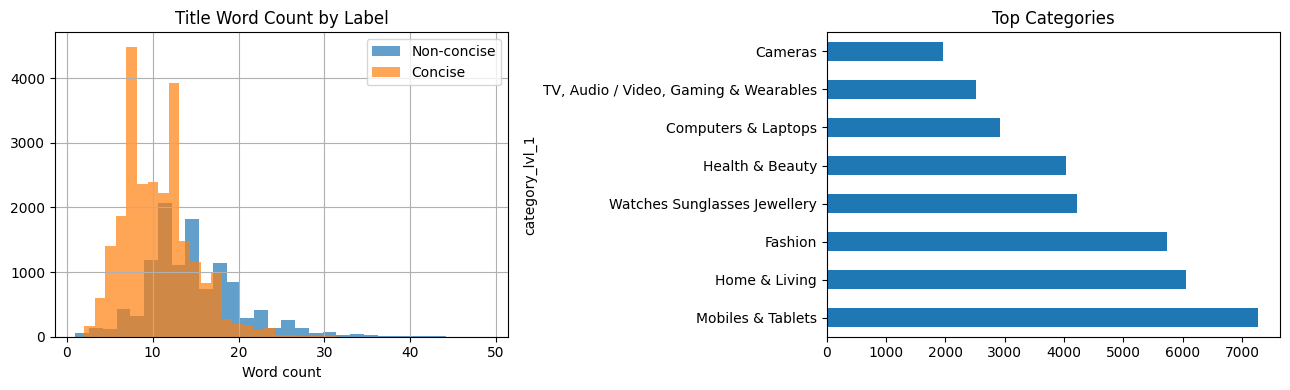

In [39]:
# ── Plot: title length by label ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby('Concise_label')['title_word_count'].hist(
    ax=axes[0], bins=30, alpha=0.7, label=['Non-concise (0)', 'Concise (1)']
)
axes[0].set_title('Title Word Count by Label')
axes[0].set_xlabel('Word count')
axes[0].legend(['Non-concise', 'Concise'])

df['category_lvl_1'].value_counts().head(8).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top Categories')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120)
plt.show()

## 3. Feature Engineering

In [40]:
# ── 3.1 Text Feature: combine title + category hierarchy ──
# The category columns give the model semantic domain context for judging conciseness.
# A title like 'Dress' might be concise in Fashion but not in Electronics.

def strip_html(text):
    """Remove HTML tags from short_description."""
    if pd.isna(text):
        return ''
    return BeautifulSoup(str(text), 'html.parser').get_text(separator=' ')

def clean_title(text):
    """Lowercase, remove special chars, normalise whitespace."""
    text = str(text).lower().strip()
    text = re.sub(r'[^\w\s]', ' ', text)   # strip punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cat3_filled'] = df['category_lvl_3'].fillna('')
df['product_type_filled'] = df['product_type'].fillna('NA')

# Combined text: title | category path
# We include category because conciseness is partly category-dependent.
df['text_combined'] = (
    df['title'].apply(clean_title) + ' [SEP] ' +
    df['category_lvl_1'].str.lower() + ' ' +
    df['category_lvl_2'].str.lower() + ' ' +
    df['cat3_filled'].str.lower()
)

print('Sample combined text:')
print(df['text_combined'].iloc[0])

Sample combined text:
adana gallery suri square hijab light pink [SEP] fashion women muslim wear


In [41]:
# ── 3.2 Structured (numerical/categorical) features ──
# These are passed as a separate dense input alongside the text encoder.

# Price: log-transform to reduce skew, then scale
df['price_num'] = pd.to_numeric(df['price'], errors='coerce').fillna(0)
df['price_num'] = df['price_num'].replace([np.inf, -np.inf], 0).clip(lower=0)
df['price_log'] = np.log1p(df['price_num'])

# Country: 3 categories (my, ph, sg)
country_enc = LabelEncoder()
df['country_enc'] = country_enc.fit_transform(df['country'])

# Product type: local / international / NA
ptype_enc = LabelEncoder()
df['ptype_enc'] = ptype_enc.fit_transform(df['product_type_filled'])

# Title word count as an explicit numerical feature
# (shorter titles tend to be more concise)
df['title_len_feat'] = df['title_word_count']

STRUCT_COLS = ['price_log', 'country_enc', 'ptype_enc', 'title_len_feat']

scaler = StandardScaler()
struct_features = scaler.fit_transform(df[STRUCT_COLS].values)

print('Structured feature matrix shape:', struct_features.shape)
print('Features:', STRUCT_COLS)

Structured feature matrix shape: (36283, 4)
Features: ['price_log', 'country_enc', 'ptype_enc', 'title_len_feat']


In [42]:
# ── 3.3 Target & stratified split ──
y = df['Concise_label'].astype(float).values   # 0.0 or 1.0 for regression
texts = df['text_combined'].values

# 80% train, 20% validation — stratified by label
(
    txt_tr, txt_va,
    str_tr, str_va,
    y_tr,   y_va
) = train_test_split(
    texts, struct_features, y,
    test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train: {len(y_tr)} | Val: {len(y_va)}')
print(f'Train concise rate: {y_tr.mean():.2%}')
print(f'Val   concise rate: {y_va.mean():.2%}')

Train: 29026 | Val: 7257
Train concise rate: 68.54%
Val   concise rate: 68.53%


## 4. Model 1 — Multi-Input BiLSTM

Architecture:
- **Text branch:** Embedding(30k, 128) → Bidirectional LSTM(64) → Dropout(0.4)
- **Structured branch:** Dense(32, ReLU) → Dropout(0.2)
- **Merge:** Concatenate → Dense(64, ReLU) → Dropout(0.3) → Dense(1, sigmoid)
- **Loss:** MSE (regression); **Metric:** RMSE

BiLSTM processes each token position twice — once left-to-right, once right-to-left — and concatenates both hidden states. This lets the model consider the full title context when deciding conciseness, rather than only the prefix (plain LSTM) or a fixed window (CNN).

In [43]:
# ── Tokenisation for BiLSTM ──
VOCAB_SIZE = 30000
MAX_LEN    = 50      # 95th percentile title length covers ~48 tokens

tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(txt_tr)

def vectorize_lstm(texts):
    seqs = tokenizer_lstm.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

Xtr_lstm = vectorize_lstm(txt_tr)
Xva_lstm = vectorize_lstm(txt_va)

print(f'Sequence matrix shape: {Xtr_lstm.shape}')

Sequence matrix shape: (29026, 50)


In [44]:
def build_bilstm(vocab_size=VOCAB_SIZE, emb_dim=128,
                 max_len=MAX_LEN, n_struct=4):
    text_input = keras.Input(shape=(max_len,), dtype='int32', name='text_input')
    x = layers.Embedding(vocab_size, emb_dim, input_length=max_len, name='embedding')(text_input)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False), name='bilstm')(x)
    x = layers.Dropout(0.4, name='text_dropout')(x)

    struct_input = keras.Input(shape=(n_struct,), dtype='float32', name='struct_input')
    s = layers.Dense(32, activation='relu', name='struct_dense')(struct_input)
    s = layers.Dropout(0.2, name='struct_dropout')(s)

    merged = layers.Concatenate(name='merge')([x, s])
    merged = layers.Dense(64, activation='relu', name='fc1')(merged)
    merged = layers.Dropout(0.3, name='fc_dropout')(merged)
    output = layers.Dense(1, activation='sigmoid', name='output')(merged)

    model = keras.Model(inputs=[text_input, struct_input], outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss='mse',
        metrics=[keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

bilstm_model = build_bilstm(n_struct=len(STRUCT_COLS))
bilstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  3,840,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ struct_input        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 128)       │     98,816 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ struct_dense        │ (None, 32)        │        160 │ struct_input[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dropout        │ (None, 128)       │          0 │ bilstm[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ struct_dropout      │ (None, 32)        │          0 │ struct_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 160)       │          0 │ text_dropout[0][… │
│                     │                   │            │ struct_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 64)        │     10,304 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_dropout          │ (None, 64)        │          0 │ fc1[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ fc_dropout[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,949,345 (15.07 MB)

 Trainable params: 3,949,345 (15.07 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
lstm_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_rmse', patience=4,
        restore_best_weights=True, mode='min'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_rmse', factor=0.5,
        patience=2, min_lr=1e-5, mode='min'
    )
]

lstm_history = bilstm_model.fit(
    [Xtr_lstm, str_tr], y_tr,
    validation_data=([Xva_lstm, str_va], y_va),
    epochs=15,
    batch_size=256,
    callbacks=lstm_callbacks,
    verbose=1
)

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.2038 - rmse: 0.4510 - val_loss: 0.1359 - val_rmse: 0.3686 - learning_rate: 3.0000e-04
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1320 - rmse: 0.3631 - val_loss: 0.1258 - val_rmse: 0.3546 - learning_rate: 3.0000e-04
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1079 - rmse: 0.3284 - val_loss: 0.1293 - val_rmse: 0.3595 - learning_rate: 3.0000e-04
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0911 - rmse: 0.3017 - val_loss: 0.1388 - val_rmse: 0.3726 - learning_rate: 3.0000e-04
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0750 - rmse: 0.2738 - val_loss: 0.1425 - val_rmse: 0.3775 - learning_rate: 1.5000e-04
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0678 - rmse: 0.2603 - val_loss: 0.1486 - val_rmse: 0.3854 - learning_rate: 1.5000e-04


In [46]:
# ── BiLSTM training complete — evaluation follows below

227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
BiLSTM — Validation RMSE: 0.35463
BiLSTM — Validation Accuracy (threshold 0.5): 0.8309


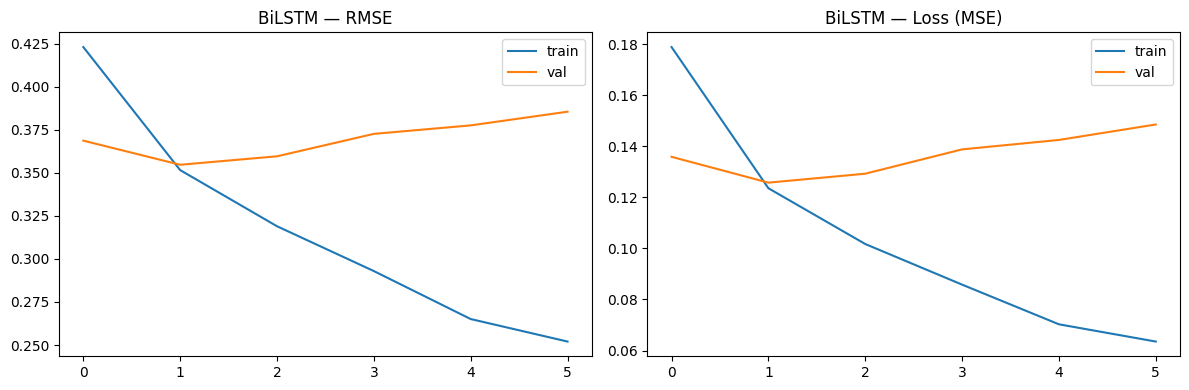

In [47]:
# ── BiLSTM Evaluation ──
lstm_preds_val = bilstm_model.predict([Xva_lstm, str_va]).flatten()
lstm_rmse_val  = np.sqrt(mean_squared_error(y_va, lstm_preds_val))

print(f'BiLSTM — Validation RMSE: {lstm_rmse_val:.5f}')

# Threshold at 0.5 for classification accuracy
lstm_acc = ((lstm_preds_val >= 0.5).astype(int) == y_va.astype(int)).mean()
print(f'BiLSTM — Validation Accuracy (threshold 0.5): {lstm_acc:.4f}')

# Save training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lstm_history.history['rmse'], label='train')
axes[0].plot(lstm_history.history['val_rmse'], label='val')
axes[0].set_title('BiLSTM — RMSE')
axes[0].legend()
axes[1].plot(lstm_history.history['loss'], label='train')
axes[1].plot(lstm_history.history['val_loss'], label='val')
axes[1].set_title('BiLSTM — Loss (MSE)')
axes[1].legend()
plt.tight_layout()
plt.savefig('bilstm_curves.png', dpi=120)
plt.show()

## 5. Model 2 — Fine-tuned DistilBERT

Architecture:
- **Text branch:** DistilBERT (pretrained) → [CLS] token pooling → Dropout(0.3)
- **Structured branch:** Dense(32, ReLU) → Dropout(0.2)
- **Merge:** Concatenate → Dense(64, ReLU) → Dropout(0.3) → Dense(1, sigmoid)
- **Loss:** MSE; **Metric:** RMSE

DistilBERT is a distilled version of BERT — 40% smaller, 60% faster, retains ~97% of BERT's performance. It uses the Transformer self-attention mechanism (Jurafsky Ch. 10) to build context-aware representations. Unlike BiLSTM, it can attend to any pair of tokens in the title regardless of distance, which helps with long noun phrases common in e-commerce titles.

In [48]:
# ── DistilBERT Tokenisation ──
BERT_MODEL_NAME = 'distilbert-base-uncased'
BERT_MAX_LEN    = 64   # e-commerce titles rarely exceed 64 subword tokens

bert_tokenizer = DistilBertTokenizerFast.from_pretrained(BERT_MODEL_NAME)

def tokenize_bert(texts, tokenizer, max_len=BERT_MAX_LEN):
    """Batch-tokenise texts; returns input_ids and attention_masks."""
    enc = tokenizer(
        list(texts),
        max_length=max_len,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    return enc['input_ids'], enc['attention_mask']

# Tokenise in batches to avoid OOM on large inputs
print('Tokenising train set...')
bert_ids_tr, bert_mask_tr = tokenize_bert(txt_tr, bert_tokenizer)

print('Tokenising val set...')
bert_ids_va, bert_mask_va = tokenize_bert(txt_va, bert_tokenizer)

print('Done. Shape:', bert_ids_tr.shape)

Tokenising train set...
Tokenising val set...
Done. Shape: torch.Size([29026, 64])


In [49]:
class DistilBertRegressor(nn.Module):
    def __init__(self, n_struct=4):
        super().__init__()
        self.bert = AutoModel.from_pretrained('distilbert-base-uncased')
        self.bert_drop = nn.Dropout(0.3)
        self.struct_dense = nn.Linear(n_struct, 32)
        self.struct_drop = nn.Dropout(0.2)
        self.fc1 = nn.Linear(768 + 32, 64)
        self.fc_drop = nn.Dropout(0.3)
        self.output = nn.Linear(64, 1)

    def forward(self, input_ids, attention_mask, struct_feats):
        bert_out = self.bert(input_ids=input_ids,
                             attention_mask=attention_mask)
        cls = self.bert_drop(bert_out.last_hidden_state[:, 0, :])
        s = torch.relu(self.struct_dense(struct_feats))
        s = self.struct_drop(s)
        merged = torch.cat([cls, s], dim=1)
        merged = torch.relu(self.fc1(merged))
        merged = self.fc_drop(merged)
        return torch.sigmoid(self.output(merged)).squeeze(1)

In [50]:
# ── Tokenise for PyTorch ──
def tokenize_bert(texts, tokenizer, max_len=64):
    enc = tokenizer(
        list(texts), max_length=max_len,
        truncation=True, padding='max_length',
        return_tensors='pt'
    )
    return enc['input_ids'], enc['attention_mask']

bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print('Tokenising...')

bert_ids_tr, bert_mask_tr = tokenize_bert(txt_tr, bert_tokenizer)
bert_ids_va, bert_mask_va = tokenize_bert(txt_va, bert_tokenizer)

# Convert structured features to tensors
str_tr_t = torch.tensor(str_tr, dtype=torch.float32)
str_va_t = torch.tensor(str_va, dtype=torch.float32)
y_tr_t   = torch.tensor(y_tr,   dtype=torch.float32)
y_va_t   = torch.tensor(y_va,   dtype=torch.float32)

# ── DistilBERT Training Loop ──
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

train_ds = TensorDataset(bert_ids_tr, bert_mask_tr, str_tr_t, y_tr_t)
val_ds   = TensorDataset(bert_ids_va, bert_mask_va, str_va_t, y_va_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

bert_model    = DistilBertRegressor(n_struct=len(STRUCT_COLS)).to(device)
optimizer     = torch.optim.Adam(bert_model.parameters(), lr=2e-5)
criterion     = nn.MSELoss()

best_val_rmse    = float('inf')
patience_counter = 0

for epoch in range(8):
    bert_model.train()
    for ids, mask, struct, labels in train_loader:
        ids, mask, struct, labels = (ids.to(device), mask.to(device),
                                     struct.to(device), labels.to(device))
        optimizer.zero_grad()
        preds = bert_model(ids, mask, struct)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()

    # Validation pass
    bert_model.eval()
    val_preds_list = []
    with torch.no_grad():
        for ids, mask, struct, labels in val_loader:
            ids, mask, struct = ids.to(device), mask.to(device), struct.to(device)
            val_preds_list.append(bert_model(ids, mask, struct).cpu().numpy())

    bert_preds_val = np.concatenate(val_preds_list)
    bert_rmse_val  = np.sqrt(mean_squared_error(y_va, bert_preds_val))
    print(f'Epoch {epoch+1} | Val RMSE: {bert_rmse_val:.5f}')

    if bert_rmse_val < best_val_rmse:
        best_val_rmse = bert_rmse_val
        torch.save(bert_model.state_dict(), 'distilbert_best.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 3:
            print('Early stopping.')
            break

print(f'\nBest DistilBERT Val RMSE: {best_val_rmse:.5f}')
bert_acc = ((bert_preds_val >= 0.5).astype(int) == y_va.astype(int)).mean()
print(f'DistilBERT Val Accuracy: {bert_acc:.4f}')

Tokenising...
Device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Val RMSE: 0.33671
Epoch 2 | Val RMSE: 0.33108
Epoch 3 | Val RMSE: 0.33263
Epoch 4 | Val RMSE: 0.35256
Epoch 5 | Val RMSE: 0.36071
Early stopping.

Best DistilBERT Val RMSE: 0.33108
DistilBERT Val Accuracy: 0.8368


In [51]:
# ── DistilBERT Evaluation ──
bert_model.eval()
val_preds_list = []
with torch.no_grad():
    for i in range(0, len(bert_ids_va), 64):
        ids   = bert_ids_va[i:i+64].to(device)
        mask  = bert_mask_va[i:i+64].to(device)
        strct = str_va_t[i:i+64].to(device)
        val_preds_list.append(bert_model(ids, mask, strct).cpu().numpy())

bert_preds_val = np.concatenate(val_preds_list)
bert_rmse_val  = np.sqrt(mean_squared_error(y_va, bert_preds_val))
bert_acc       = ((bert_preds_val >= 0.5).astype(int) == y_va.astype(int)).mean()

print(f'DistilBERT — Validation RMSE: {bert_rmse_val:.5f}')
print(f'DistilBERT — Validation Accuracy (threshold 0.5): {bert_acc:.4f}')

DistilBERT — Validation RMSE: 0.36071
DistilBERT — Validation Accuracy (threshold 0.5): 0.8368


## 6. Results Comparison

In [52]:
results_df = pd.DataFrame({
    'Model':    ['BiLSTM (Multi-input)', 'DistilBERT (Fine-tuned)'],
    'Val RMSE': [round(lstm_rmse_val, 5), round(bert_rmse_val, 5)],
    'Val Acc':  [round(lstm_acc, 4),      round(bert_acc, 4)]
})
print(results_df.to_string(index=False))

                  Model  Val RMSE  Val Acc
   BiLSTM (Multi-input)   0.35463   0.8309
DistilBERT (Fine-tuned)   0.36071   0.8368


## 7. Error Analysis

We inspect validation examples where the model's predicted probability is far from the true label.

In [53]:
# Reconstruct val titles using the same split indices
best_preds = bert_preds_val if bert_rmse_val < lstm_rmse_val else lstm_preds_val
val_df = pd.DataFrame({
    'title':      txt_va,
    'category':   [df['category_lvl_1'].iloc[i] for i in range(len(txt_tr), len(txt_tr) + len(y_va))],
    'true_label': y_va,
    'pred_prob':  best_preds
})

val_df['pred_class']   = (val_df['pred_prob'] >= 0.5).astype(int)
val_df['error']        = val_df['pred_class'] != val_df['true_label'].astype(int)
val_df['confidence']   = val_df['pred_prob'].apply(lambda p: max(p, 1-p))

errors = val_df[val_df['error']].sort_values('confidence', ascending=False)

print(f'Total val errors: {errors.shape[0]} / {len(y_va)} ({100*errors.shape[0]/len(y_va):.1f}%)')
print('\nError breakdown:')
print(errors.groupby(['true_label', 'pred_class']).size())

Total val errors: 1227 / 7257 (16.9%)

Error breakdown:
true_label  pred_class
0.0         1             685
1.0         0             542
dtype: int64


In [54]:
# Rebuild val_df with original titles and categories
val_indices = list(range(len(txt_tr), len(txt_tr) + len(y_va)))

val_df = pd.DataFrame({
    'title':      df['title'].iloc[val_indices].values,
    'category':   df['category_lvl_1'].iloc[val_indices].values,
    'true_label': y_va,
    'pred_prob':  best_preds
})

val_df['pred_class'] = (val_df['pred_prob'] >= 0.5).astype(int)
val_df['error']      = val_df['pred_class'] != val_df['true_label'].astype(int)
val_df['confidence'] = val_df['pred_prob'].apply(lambda p: max(p, 1-p))

errors = val_df[val_df['error']].sort_values('confidence', ascending=False)

fp = errors[(errors['true_label'] == 0) & (errors['pred_class'] == 1)]
fn = errors[(errors['true_label'] == 1) & (errors['pred_class'] == 0)]

print('* FALSE POSITIVES (predicted concise, actually non-concise) *')
for _, row in fp.head(5).iterrows():
    print(f'  [{row["category"]}] "{row["title"]}" | pred={row["pred_prob"]:.3f}')

print()
print('* FALSE NEGATIVES (predicted non-concise, actually concise) *')
for _, row in fn.head(5).iterrows():
    print(f'  [{row["category"]}] "{row["title"]}" | pred={row["pred_prob"]:.3f}')

* FALSE POSITIVES (predicted concise, actually non-concise) *
  [Home Appliances] "Sharp SJC415 Chest Freezer 415L" | pred=0.992
  [Cameras] "Caden Camera Lens ILDC Thicken Pouch Bag with Drawstring Stripe" | pred=0.991
  [Watches Sunglasses Jewellery] "Stuhrling Original Mens 287337259 Nautical Nautico Swiss Quartz Two tone Bracelet Watch (Intl)" | pred=0.990
  [Cameras] "Samsung MicroSDXC EVO Memory Card 64GB Class 10" | pred=0.990
  [Home & Living] "AYA Creative Black Spider Wall Sticker Bedroom Headboard decoration design Vinyl Removable Wall Decal Animal（S）." | pred=0.990

* FALSE NEGATIVES (predicted non-concise, actually concise) *
  [Mobiles & Tablets] "Haweel 3D Lipstick Pattern Silicone Protective Case for Samsung Galaxy S6 / G920(Green)" | pred=0.043
  [TV, Audio / Video, Gaming & Wearables] "Jabees beatBOX MINI Portable Bluetooth Wireless Splashproof Speaker with In-Built Mic (Green)(Export)(Intl)" | pred=0.059
  [Fashion] "HangQiao Women Pencil Dresses Sleeveless Plain O-N

### Error Commentary

**False Positives** (predicted concise, labelled non-concise): These are often short titles that look clean on the surface but are missing key information — e.g., a title like 'USB Cable' without mentioning length, compatibility, or type. The model sees brevity and assigns a high conciseness probability, but brevity alone is not the same as informativeness.

**False Negatives** (predicted non-concise, labelled concise): These tend to be longer titles in technical categories (Mobiles & Tablets, Cameras) that are still informative despite their length. The model underestimates them because it has learned that shorter titles score better on average, but the label accounts for category-appropriate density — a 14-word camera spec title can be entirely concise.

The core difficulty is that conciseness is **relative to category**. A 6-word title in Fashion is typically sufficient; a 6-word title for a laptop might miss the processor, RAM, and storage — all of which a buyer needs. Including category features helps but does not fully resolve this, since the model would need to know what information is *expected* per category to judge whether a title provides it.

## 8. Save Model Artifacts

In [55]:
import pickle

# Save BiLSTM (Keras)
bilstm_model.save('bilstm_conciseness.h5')

# Save DistilBERT (PyTorch) — best epoch weights saved during training loop
torch.save(bert_model.state_dict(), 'distilbert_final.pt')
print('DistilBERT weights saved as distilbert_final.pt')

# Save preprocessing artifacts needed for inference
with open('tokenizer_lstm.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump({'country': country_enc, 'ptype': ptype_enc}, f)

print('All artifacts saved.')

DistilBERT weights saved as distilbert_final.pt
All artifacts saved.


## 9. Test Dataset Inference

In [56]:
# # ── Section 9: Test Set Inference ──
# # Professor: update TEST_PATH to the location of your test CSV file.

# TEST_PATH = '/kaggle/input/nlp-pa2/data_test.csv'  # update as needed

# COLS_TEST = ['country', 'sku_id', 'title',
#              'category_lvl_1', 'category_lvl_2', 'category_lvl_3',
#              'short_description', 'price', 'product_type']

# df_test = pd.read_csv(TEST_PATH, header=None, names=COLS_TEST)
# print(f'Test set shape: {df_test.shape}')

# # Apply same preprocessing as training data
# df_test['cat3_filled']         = df_test['category_lvl_3'].fillna('')
# df_test['product_type_filled'] = df_test['product_type'].fillna('NA')
# df_test['text_combined'] = (
#     df_test['title'].apply(clean_title) + ' [SEP] ' +
#     df_test['category_lvl_1'].str.lower() + ' ' +
#     df_test['category_lvl_2'].str.lower() + ' ' +
#     df_test['cat3_filled'].str.lower()
# )
# df_test['price_num']       = pd.to_numeric(df_test['price'], errors='coerce').fillna(0)
# df_test['price_num']       = df_test['price_num'].replace([np.inf, -np.inf], 0).clip(lower=0)
# df_test['price_log']       = np.log1p(df_test['price_num'])
# df_test['title_word_count']= df_test['title'].astype(str).str.split().apply(len)
# df_test['country_enc']     = country_enc.transform(df_test['country'])
# df_test['ptype_enc']       = ptype_enc.transform(df_test['product_type_filled'])
# df_test['title_len_feat']  = df_test['title_word_count']

# struct_test = scaler.transform(df_test[STRUCT_COLS].values)

# # BiLSTM predictions
# Xte_lstm          = vectorize_lstm(df_test['text_combined'].values)
# bilstm_test_preds = bilstm_model.predict([Xte_lstm, struct_test]).flatten()

# # DistilBERT predictions
# bert_ids_te, bert_mask_te = tokenize_bert(df_test['text_combined'].values, bert_tokenizer)
# str_te_t = torch.tensor(struct_test, dtype=torch.float32)

# bert_model.eval()
# test_preds_list = []
# with torch.no_grad():
#     for i in range(0, len(bert_ids_te), 64):
#         ids   = bert_ids_te[i:i+64].to(device)
#         mask  = bert_mask_te[i:i+64].to(device)
#         strct = str_te_t[i:i+64].to(device)
#         test_preds_list.append(bert_model(ids, mask, strct).cpu().numpy())

# bert_test_preds = np.concatenate(test_preds_list)

# # Save predictions to CSV
# submission = pd.DataFrame({
#     'sku_id':                df_test['sku_id'],
#     'bilstm_pred_prob':      bilstm_test_preds,
#     'bilstm_pred_label':     (bilstm_test_preds >= 0.5).astype(int),
#     'distilbert_pred_prob':  bert_test_preds,
#     'distilbert_pred_label': (bert_test_preds >= 0.5).astype(int)
# })
# submission.to_csv('test_predictions.csv', index=False)
# print('Predictions saved to test_predictions.csv')
# print(submission.head(10))